# Defects4J EDA
Primary Question: What do these bugs and fixes look like, and how hard are they to repair?

In [37]:
# basic imports
import pandas as pd 
import numpy as np 

from pathlib import Path #universal file paths
import matplotlib.pyplot as plt
from urllib.parse import urlparse

In [2]:
# paths
D4J_ROOT = Path("/Users/louisas/GitHub/defects4j")
PROJECTS_DIR = D4J_ROOT / "framework" / "projects"

#build dataframe (one row per active bug)
def load_bug_csv(projects_dir: Path, filename: str) -> pd.DataFrame:
    """Load active-bugs.csv from every project folder and combine them
    into a single DataFrame with an added 'project' column."""
    frames = []
    #extract project active-bugs.csv from each project folder
    for csv_path in sorted(projects_dir.glob(f"*/{filename}")):
        project = csv_path.parent.name  #folder name = project name
        df = pd.read_csv(csv_path)
        df['project'] = project     #tag every row with corresponding project
        frames.append(df)
    return pd.concat(frames, ignore_index=True)     #stack projects into one table with fresh index

In [3]:
#look at active bugs csvs
bugs = load_bug_csv(PROJECTS_DIR, "active-bugs.csv")
bugs.columns = bugs.columns.str.replace(".", "_", regex=False)  #replace '.' in column names with '_'
bugs["bug_key"] = bugs["project"] + "-" + bugs["bug_id"].astype(str)    #unique identifier per bug, e.g. "Lang-1"

#sanity check
print("active bugs shape:", bugs.shape)   #(number of bugs, number of columns)
print("\nactive bugs column names:", bugs.columns.tolist())    #confim column renaming
print("\nactive bug count per project:\n", bugs["project"].value_counts()) #count bugs per project
assert bugs["bug_key"].is_unique #each bug should appear exactly once, raise AssertionError if false

active bugs shape: (854, 7)

active bugs column names: ['bug_id', 'revision_id_buggy', 'revision_id_fixed', 'report_id', 'report_url', 'project', 'bug_key']

active bug count per project:
 project
Closure            174
JacksonDatabind    110
Math               106
Jsoup               93
Lang                61
Compress            47
Cli                 39
Mockito             38
Collections         28
Chart               26
JacksonCore         26
Time                26
JxPath              22
Gson                18
Codec               18
Csv                 16
JacksonXml           6
Name: count, dtype: int64


Observation: heavy class imbalance across projects

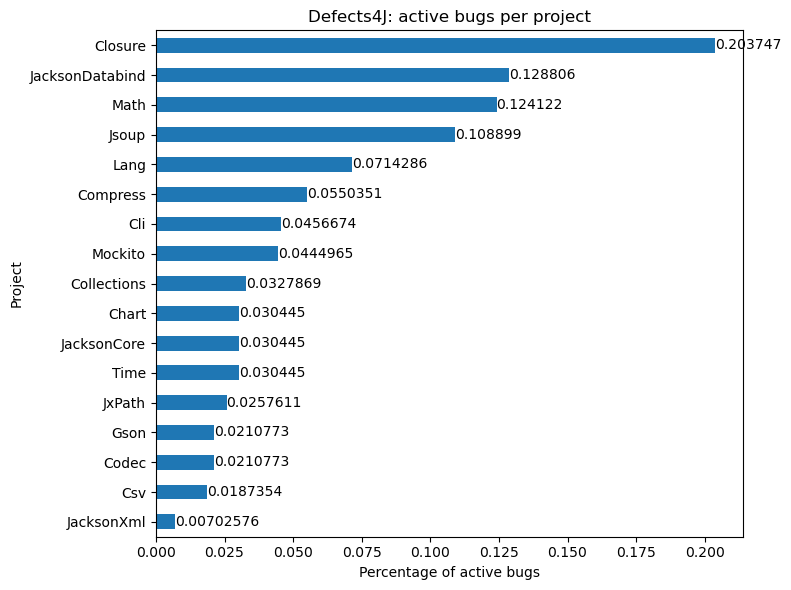

In [4]:
counts = bugs["project"].value_counts(normalize=True).sort_values()   # ascending, so the largest bar ends up on top

fig, ax = plt.subplots(figsize=(8, 6))
counts.plot(kind="barh", ax=ax)

ax.set_xlabel("Percentage of active bugs")
ax.set_ylabel("Project")
ax.set_title("Defects4J: active bugs per project")
ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

In [5]:
#look at deprecated bugs
deprecated = load_bug_csv(PROJECTS_DIR, "deprecated-bugs.csv")
deprecated.columns = deprecated.columns.str.replace(".", "_", regex=False)  #replace '.' in column names with '_'
deprecated["bug_key"] = deprecated["project"] + "-" + deprecated["bug_id"].astype(str)    #unique identifier per bug, e.g. "Lang-1"

#sanity check
print("deprecated shape:", deprecated.shape)   #(number of bugs, number of columns)
print("\ndeprecated column names:", deprecated.columns.tolist())    #confim column renaming
print("\ndeprecated reason column values count:", deprecated['deprecated_reason'].value_counts())
print("\ndeprecated projects value count:", deprecated["project"].value_counts()) #count bugs per project
assert deprecated["bug_key"].is_unique #each bug should appear exactly once, raise AssertionError if false
overlap = deprecated["bug_key"].isin(bugs["bug_key"])
assert not overlap.any() #raise AssertionError if deprecated bus appear in active bugs

active_counts = bugs["project"].value_counts()
dep_counts = deprecated["project"].value_counts().reindex(active_counts.index, fill_value=0)

deprecation_rate = (dep_counts / (active_counts + dep_counts)).sort_values(ascending=False)
print("\ndeprecation rate:", deprecation_rate.round(3))

deprecated shape: (10, 9)

deprecated column names: ['bug_id', 'revision_id_buggy', 'revision_id_fixed', 'report_id', 'report_url', 'deprecated_version', 'deprecated_reason', 'project', 'bug_key']

deprecated reason column values count: deprecated_reason
JVM8.Not.Reproducible    3
Duplicate                3
JVM11.Not.Repoducible    3
JVM11.flaky              1
Name: count, dtype: int64

deprecated projects value count: project
Lang               4
Closure            2
JacksonDatabind    2
Cli                1
Time               1
Name: count, dtype: int64

deprecation rate: project
Lang               0.062
Time               0.037
Cli                0.025
JacksonDatabind    0.018
Closure            0.011
JacksonCore        0.000
Csv                0.000
Codec              0.000
Gson               0.000
JxPath             0.000
Collections        0.000
Chart              0.000
Mockito            0.000
Compress           0.000
Jsoup              0.000
Math               0.000
JacksonXml 

Observations:
- typo in source data "JVM11.Not.Repoducible" missing r in reproducible
- 6 bugs are not reproducible on JVM8 and JVM 11
- 3 duplicate bugs (remove in cleaning)
- highest deprecation rate is Lang with 4/65 bugs (6.2%)


In [6]:
print("Print example patch:\n")
print((PROJECTS_DIR / "Chart" / "patches" / "2.src.patch").read_text())

Print example patch:

diff --git a/source/org/jfree/data/general/DatasetUtilities.java b/source/org/jfree/data/general/DatasetUtilities.java
index 548d684..927cbad 100644
--- a/source/org/jfree/data/general/DatasetUtilities.java
+++ b/source/org/jfree/data/general/DatasetUtilities.java
@@ -752,19 +752,12 @@ public final class DatasetUtilities {
             for (int series = 0; series < seriesCount; series++) {
                 int itemCount = dataset.getItemCount(series);
                 for (int item = 0; item < itemCount; item++) {
-                    double value = intervalXYData.getXValue(series, item);
                     lvalue = intervalXYData.getStartXValue(series, item);
                     uvalue = intervalXYData.getEndXValue(series, item);
-                    if (!Double.isNaN(value)) {
-                        minimum = Math.min(minimum, value);
-                        maximum = Math.max(maximum, value);
-                    }
                     if (!Double.isNaN(l

In [7]:
def parse_patch(patch_path: Path) -> dict:
    """Count files, hunks, and added/removed lines in one Defects4J patch."""
    text = patch_path.read_text(encoding="utf-8", errors="replace")

    n_files = n_hunks = n_added = n_removed = 0
    for line in text.splitlines():
        if line.startswith("+++"):   #one +++ header per file, in git AND svn diffs
            n_files += 1
        elif line.startswith("---"):    #elif starts with "+++" or "---" -> header, skip
            continue    #file name header, not a real change
        elif line.startswith("@@"):     #elif starts with "@@" -> one more hunk
            n_hunks += 1
        elif line.startswith("+"):     #elif starts with "+" -> added line
            n_added +=1
        elif line.startswith("-"):   #elif starts with "-" -> removed line
            n_removed +=1

    return {
        "n_files": n_files,
        "n_hunks": n_hunks,
        "n_buggy_lines": n_added,     # "+" lines = buggy code (D4J patches go fixed -> buggy)
        "n_fix_lines": n_removed,     # "-" lines = the developer's fix
        "n_changed": n_added + n_removed,
    }

#sanity check
patch_path = PROJECTS_DIR / "Lang" / "patches" / "1.src.patch"
patch = parse_patch(patch_path)
print(patch)

{'n_files': 1, 'n_hunks': 1, 'n_buggy_lines': 2, 'n_fix_lines': 11, 'n_changed': 13}


In [ ]:
#run parse_patch function on patches
rows = []
for project, bug_id in zip(bugs["project"], bugs["bug_id"]):
    patch_path = PROJECTS_DIR / project / "patches" / f"{bug_id}.src.patch"
    rows.append(parse_patch(patch_path))

patch_stats = pd.DataFrame(rows)
bugs = bugs.drop(columns=patch_stats.columns, errors="ignore")
bugs = pd.concat([bugs, patch_stats], axis=1)

print(bugs[["bug_key", "n_files", "n_hunks", "n_changed"]].head())
print("sanity check (should be 1):", bugs["n_files"].min()) 
print(bugs[["n_files", "n_hunks", "n_buggy_lines", "n_fix_lines", "n_changed"]].describe())

   bug_key  n_files  n_hunks  n_changed
0  Chart-1        1        1          2
1  Chart-2        1        2         14
2  Chart-3        1        1          2
3  Chart-4        1        2          2
4  Chart-5        1        1          6
sanity check (should be 1): 1
          n_files     n_hunks  n_buggy_lines  n_fix_lines   n_changed
count  854.000000  854.000000     854.000000   854.000000  854.000000
mean     1.256440    2.288056       2.860656     9.288056   12.148712
std      0.878851    2.926441       6.139490    25.128349   27.808930
min      1.000000    1.000000       0.000000     0.000000    1.000000
25%      1.000000    1.000000       0.000000     2.000000    3.000000
50%      1.000000    1.000000       1.000000     4.000000    6.000000
75%      1.000000    2.000000       2.000000     9.000000   12.000000
max     16.000000   47.000000      77.000000   624.000000  630.000000


In [9]:
def classify_patch(row) -> str:
    """Label a bug's fix by complexity, from simplest to most complex."""
    if row["n_hunks"] == 1 and row["n_fix_lines"] <= 1 and row["n_buggy_lines"] <= 1:    # 1 hunk AND fix lines <= 1 AND buggy lines <= 1
        return "single-line"
    elif row["n_hunks"] == 1:   # 1 hunk
        return "single-hunk"
    elif row["n_files"] == 1:   # 1 file
        return "single-file, multi-hunk"
    else:
        return "multi-file"

bugs["complexity"] = bugs.apply(classify_patch, axis=1)
print(bugs["complexity"].value_counts())

complexity
single-hunk                301
single-file, multi-hunk    254
single-line                172
multi-file                 127
Name: count, dtype: int64


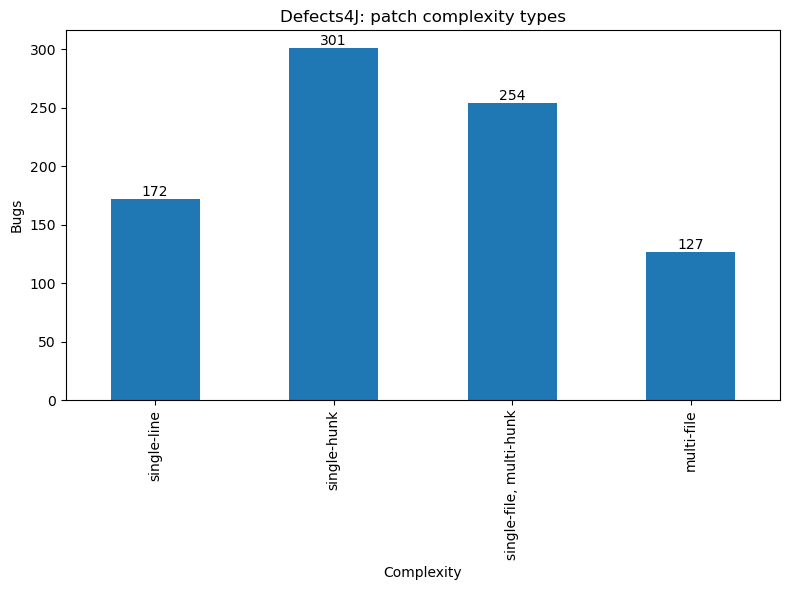

In [ ]:
#bar chart of patch complexity
order = ["single-line", "single-hunk", "single-file, multi-hunk", "multi-file"] #define order
complexity_counts = bugs["complexity"].value_counts().reindex(order) #set order

fig, ax = plt.subplots(figsize=(8, 6))
complexity_counts.plot(kind="bar", ax=ax)

ax.set_xlabel("Complexity")
ax.set_ylabel("Bugs")
ax.set_title("Defects4J: patch complexity types")
ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

**_Complexity classification definitions:_**

**Single-line:** the fix changes at most one line of code. It has one hunk with at most one line removed from the buggy version and at most one line added in the fixed version. This covers replacing one line (e.g., minMiddleIndex → maxMiddleIndex in Chart-7), inserting one new line, or deleting one line.

**Single-hunk:** the fix is confined to one contiguous block of code but changes more than one line. Example: adding a multi-line if block for an unhandled edge case.

**Single-file, multi-hunk:** the fix edits two or more separate locations within the same source file. Example: correcting a condition in one method and updating a related return statement elsewhere in the same class.

**Multi-file:** the fix changes code in two or more source files. Example: changing a method's behavior in one class and updating a caller in another.


NOTE:
- The categories are mutually exclusive and nested by difficulty. Each bug gets the most specific label that fits, checked from simplest to most complex. Every single-line fix is technically also single-hunk and single-file, but it's labeled only as single-line.
- Line counts come from the developer's patch as provided by Defects4J, which is limited to source files (.src.patch, no test changes). Counts may include blank or comment lines if they're inside the diff.

## trigger_tests exploration:

In [ ]:
#look at example trigger_test file
print("Print example trigger_test file:\n")
print((PROJECTS_DIR / "Lang" / "trigger_tests" / "1").read_text())

Print example trigger_test file:

--- org.apache.commons.lang3.math.NumberUtilsTest::TestLang747
java.lang.NumberFormatException: For input string: "80000000"
	at java.lang.NumberFormatException.forInputString(NumberFormatException.java:65)
	at java.lang.Integer.parseInt(Integer.java:583)
	at java.lang.Integer.valueOf(Integer.java:740)
	at java.lang.Integer.decode(Integer.java:1197)
	at org.apache.commons.lang3.math.NumberUtils.createInteger(NumberUtils.java:684)
	at org.apache.commons.lang3.math.NumberUtils.createNumber(NumberUtils.java:474)
	at org.apache.commons.lang3.math.NumberUtilsTest.TestLang747(NumberUtilsTest.java:256)
	at sun.reflect.NativeMethodAccessorImpl.invoke0(Native Method)
	at sun.reflect.NativeMethodAccessorImpl.invoke(NativeMethodAccessorImpl.java:62)
	at sun.reflect.DelegatingMethodAccessorImpl.invoke(DelegatingMethodAccessorImpl.java:43)
	at java.lang.reflect.Method.invoke(Method.java:498)
	at org.junit.runners.model.FrameworkMethod$1.runReflectiveCall(FrameworkM

In [34]:
def parse_trigger_tests(path: Path) -> dict:
    """Count failing tests, stack trace lines, and exception types (first + number distinct)."""
    text = path.read_text(encoding="utf-8", errors="replace")

    n_tests = n_trace_lines = 0
    expect_exception = False        # True right after a "--- " header line
    exception_types = []
    
    for line in text.splitlines():
        if line.startswith("--- "):
            n_tests += 1
            expect_exception = True
        elif expect_exception:
            exception_types.append(line.split(":")[0].strip())  #always append exception (not just first)
            expect_exception = False
        elif line.strip().startswith("at "):
            n_trace_lines += 1

    return {
        "n_trigger_tests": n_tests,
        "n_trace_lines": n_trace_lines,
        "n_log_chars": len(text),
        "exception_type": exception_types[0] if exception_types else None,
        "n_exception_types": len(set(exception_types)),
        "exception_set": sorted(set(e.split(".")[-1] for e in exception_types))
    }

#sanity check on one test
print(parse_trigger_tests(PROJECTS_DIR / "Lang" / "trigger_tests" / "1"))

{'n_trigger_tests': 1, 'n_trace_lines': 47, 'n_log_chars': 3558, 'exception_type': 'java.lang.NumberFormatException', 'n_exception_types': 1, 'exception_set': ['NumberFormatException']}


In [35]:
# run parse_trigger_tests on every bug's trigger_tests file
rows = []
for project, bug_id in zip(bugs["project"], bugs["bug_id"]):
    test_path = PROJECTS_DIR / project / "trigger_tests" / str(bug_id)
    rows.append(parse_trigger_tests(test_path))

test_stats = pd.DataFrame(rows)
bugs = bugs.drop(columns=test_stats.columns, errors="ignore")
bugs = pd.concat([bugs, test_stats], axis=1)
bugs["exception_type"] = bugs["exception_type"].str.split(".").str[-1]

print(bugs[["n_trigger_tests", "exception_type", "n_trace_lines", "n_log_chars"]].head())
print(bugs[["n_trigger_tests", "n_trace_lines", "n_log_chars"]].describe()) #describe numeric columns
print(bugs["exception_type"].value_counts().head(15)) #value count on text column
multi = bugs[bugs["n_trigger_tests"] > 1]
print(multi["n_exception_types"].value_counts())
mixed = bugs[bugs["n_exception_types"] > 1]
print(mixed["exception_set"].astype(str).value_counts().head(10))

   n_trigger_tests             exception_type  n_trace_lines  n_log_chars
0                1       AssertionFailedError             41         2981
1                2       NullPointerException             70         5130
2                1       AssertionFailedError             40         2859
3               22       NullPointerException            843        60466
4                1  IndexOutOfBoundsException             39         2784
       n_trigger_tests  n_trace_lines    n_log_chars
count       854.000000     854.000000     854.000000
mean          2.083138      98.278689    8661.802108
std           4.334098     233.034923   23136.519995
min           1.000000      32.000000    2533.000000
25%           1.000000      40.000000    2939.250000
50%           1.000000      45.000000    3524.000000
75%           2.000000      82.000000    6650.500000
max          84.000000    3409.000000  425861.000000
exception_type
AssertionFailedError               484
ComparisonFailure        

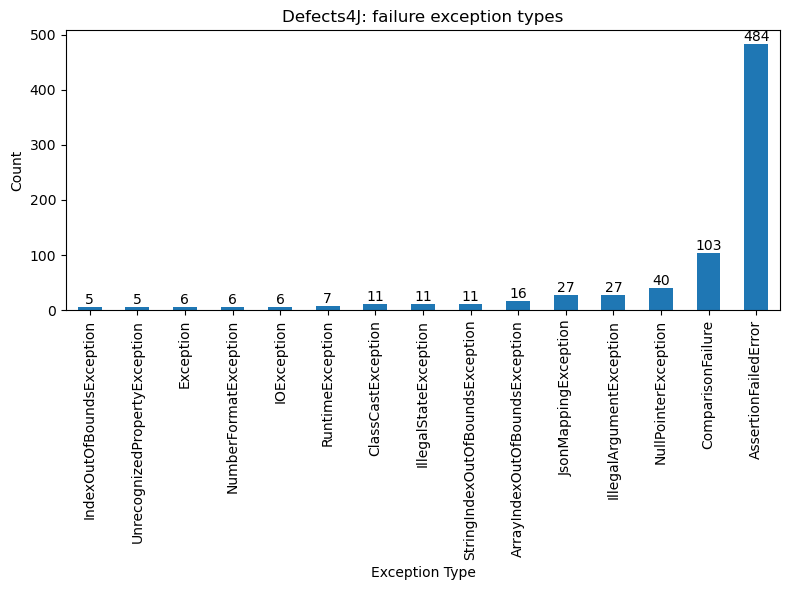

In [29]:
#bar chart of exception types
exception_types = bugs["exception_type"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
exception_types.plot(kind="bar", ax=ax)

ax.set_xlabel("Exception Type")
ax.set_ylabel("Count")
ax.set_title("Defects4J: failure exception types")
ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

In [30]:
#number of bugs with more than one failing tests
print((bugs["n_trigger_tests"] > 1).sum())

#conclusion: go back to parse_trigger_tests() function and edit to include all failures

282


In [36]:
ASSERTION_TYPES = {"AssertionFailedError", "ComparisonFailure"}

def classify_failure(row) -> str:
    excs = set(row["exception_set"])
    if excs.issubset(ASSERTION_TYPES):      # every exception is an assertion
        return "assertion"
    elif excs.isdisjoint(ASSERTION_TYPES):  # no exception is an assertion
        return "crash"
    else:                                   # some of each
        return "mixed"

bugs["failure_kind"] = bugs.apply(classify_failure, axis=1)
print(bugs["failure_kind"].value_counts())
print(bugs["failure_kind"].value_counts(normalize=True).round(3))

failure_kind
assertion    566
crash        249
mixed         39
Name: count, dtype: int64
failure_kind
assertion    0.663
crash        0.292
mixed        0.046
Name: proportion, dtype: float64


* 282 bugs (33%) have more than one failing test.
* For bugs with multiple failing tests, 77% failed with a single exception type. Only 39 bugs (4.6% of the dataset) mixed assertion failures with runtime exceptions, typically one test failing an assertion while another crashed.
* So for about 92% of bugs, the first exception fully represents the failure.

## Project overlap:

In [39]:
bugs["tracker"] = bugs["report_url"].apply(
    lambda u: urlparse(u).netloc if isinstance(u, str) else None
)
print(bugs.groupby("project")["tracker"].unique())

project
Chart                        [sourceforge.net, ]
Cli                          [issues.apache.org]
Closure                 [storage.googleapis.com]
Codec                        [issues.apache.org]
Collections                  [issues.apache.org]
Compress                     [issues.apache.org]
Csv                          [issues.apache.org]
Gson                                [github.com]
JacksonCore                         [github.com]
JacksonDatabind                     [github.com]
JacksonXml                          [github.com]
Jsoup                               [github.com]
JxPath                       [issues.apache.org]
Lang                         [issues.apache.org]
Math                         [issues.apache.org]
Mockito            [github.com, code.google.com]
Time               [github.com, sourceforge.net]
Name: tracker, dtype: object


In [43]:
#Chart project has blank in above output, investigate:
print(bugs.loc[bugs["tracker"] == "", "report_url"].unique())
print((bugs["tracker"] == "").sum())

[<NA>]
18


In [42]:
# clean up UNKNOWN (should be NaN)
bugs["report_url"] = bugs["report_url"].replace("UNKNOWN", pd.NA)

18 bugs (all from Chart, 69% of that project's bugs) have no linked bug report, recorded as UNKNOWN in the source data and treated as missing.

In [ ]:
#build table of repos in D4J
D4J_REPOS = {
    "Chart": "jfree/jfreechart",
    "Cli": "apache/commons-cli",
    "Closure": "google/closure-compiler",
    "Codec": "apache/commons-codec",
    "Collections": "apache/commons-collections",
    "Compress": "apache/commons-compress",
    "Csv": "apache/commons-csv",
    "Gson": "google/gson",
    "JacksonCore": "FasterXML/jackson-core",
    "JacksonDatabind": "FasterXML/jackson-databind",
    "JacksonXml": "FasterXML/jackson-dataformat-xml",
    "Jsoup": "jhy/jsoup",
    "JxPath": "apache/commons-jxpath",
    "Lang": "apache/commons-lang",
    "Math": "apache/commons-math",
    "Mockito": "mockito/mockito",
    "Time": "JodaOrg/joda-time",
}